In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import time
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, applications

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


2025-10-26 05:26:10.491928: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761456370.683643      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761456370.734950      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Dataset paths
DATA_ROOT = '/kaggle/input/dl-image-data-set/Forest Segmented/Forest Segmented'
IMG_DIR = os.path.join(DATA_ROOT, 'images')
MASK_DIR = os.path.join(DATA_ROOT, 'masks')
META_PATH = '/kaggle/input/dl-image-data-set/meta_data.csv'

# Read metadata
df = pd.read_csv(META_PATH)
print("Total samples:", len(df))
df.head()

# Train/Val/Test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


Total samples: 5108
Train: 3677, Val: 409, Test: 1022


In [6]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 8

def preprocess(img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    mask = cv2.resize(mask, IMG_SIZE)
    img = img / 255.0
    mask = np.expand_dims(mask, axis=-1) / 255.0
    return img, mask

class DataGen(tf.keras.utils.Sequence):
    def __init__(self, df, img_dir, mask_dir, batch_size=BATCH_SIZE, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch = self.df.iloc[idx*self.batch_size:(idx+1)*self.batch_size]
        imgs, masks = [], []
        for _, row in batch.iterrows():
            img_path = os.path.join(self.img_dir, row['image'])
            mask_path = os.path.join(self.mask_dir, row['mask'])
            img, mask = preprocess(img_path, mask_path)
            imgs.append(img)
            masks.append(mask)
        return np.array(imgs), np.array(masks)

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

train_gen = DataGen(train_df, IMG_DIR, MASK_DIR)
val_gen = DataGen(val_df, IMG_DIR, MASK_DIR)
test_gen = DataGen(test_df, IMG_DIR, MASK_DIR, shuffle=False)


In [7]:
def build_unet_resnet50(input_shape=(128,128,3), weights=None):
    base_model = applications.ResNet50(
        include_top=False, weights=weights, input_shape=input_shape
    )
    skip_connections = [
        base_model.get_layer("conv1_relu").output,
        base_model.get_layer("conv2_block3_out").output,
        base_model.get_layer("conv3_block4_out").output,
        base_model.get_layer("conv4_block6_out").output,
    ]
    encoder_output = base_model.get_layer("conv5_block3_out").output

    x = encoder_output
    for idx, skip in enumerate(reversed(skip_connections)):
        x = layers.UpSampling2D((2,2))(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(256//(2**idx), (3,3), padding="same", activation="relu")(x)
        x = layers.Conv2D(256//(2**idx), (3,3), padding="same", activation="relu")(x)

    x = layers.UpSampling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    outputs = layers.Conv2D(1, (1,1), activation="sigmoid")(x)

    model = models.Model(base_model.input, outputs)
    return model


In [8]:
def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) /
                (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth))

def combined_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

metrics = [
    tf.keras.metrics.MeanIoU(num_classes=2),
    tf.keras.metrics.BinaryAccuracy(),
    tf.keras.metrics.Precision(),
    tf.keras.metrics.Recall(),
]


I0000 00:00:1761456899.287206      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [10]:
model_scratch = build_unet_resnet50(weights=None)
model_scratch.compile(optimizer='adam', loss=combined_loss, metrics=metrics)

start_time = time.time()
history_scratch = model_scratch.fit(
    train_gen, validation_data=val_gen, epochs=100, verbose=1
)
time_scratch = time.time() - start_time


Epoch 1/100
460/460 ━━━━━━━━━━━━━━━━━━━━ 143s 153ms/step - binary_accuracy: 0.7269 - loss: 0.9865 - mean_io_u: 0.2002 - precision: 0.7624 - recall: 0.8612 - val_binary_accuracy: 0.6731 - val_loss: 0.9625 - val_mean_io_u: 0.1996 - val_precision: 0.7901 - val_recall: 0.6814
Epoch 2/100
460/460 ━━━━━━━━━━━━━━━━━━━━ 35s 75ms/step - binary_accuracy: 0.7678 - loss: 0.7412 - mean_io_u: 0.2009 - precision: 0.8036 - recall: 0.8657 - val_binary_accuracy: 0.4311 - val_loss: 2.2085 - val_mean_io_u: 0.1996 - val_precision: 0.9449 - val_recall: 0.0986
Epoch 3/100
460/460 ━━━━━━━━━━━━━━━━━━━━ 35s 75ms/step - binary_accuracy: 0.7685 - loss: 0.7314 - mean_io_u: 0.1990 - precision: 0.8017 - recall: 0.8739 - val_binary_accuracy: 0.7163 - val_loss: 0.8881 - val_mean_io_u: 0.1996 - val_precision: 0.8834 - val_recall: 0.6453
Epoch 4/100
460/460 ━━━━━━━━━━━━━━━━━━━━ 35s 75ms/step - binary_accuracy: 0.7785 - loss: 0.7056 - mean_io_u: 0.1936 - precision: 0.8120 - recall: 0.8846 - val_binary_accuracy: 0.5630 - 

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
NotebookApp.rate_limit_window=1.0 (secs)



In [13]:
# Phase 1 — Encoder frozen
model_transfer = build_unet_resnet50(weights='imagenet')
for layer in model_transfer.layers[:175]:  
    layer.trainable = False

model_transfer.compile(optimizer='adam', loss=combined_loss, metrics=metrics)
print("Phase 1: Frozen Encoder (50 epochs)")
model_transfer.fit(train_gen, validation_data=val_gen, epochs=50, verbose=1)


for layer in model_transfer.layers:
    layer.trainable = True

model_transfer.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss=combined_loss, metrics=metrics)
print("Phase 2: Fine-tuning Encoder (50 epochs)")
start_time = time.time()
model_transfer.fit(train_gen, validation_data=val_gen, epochs=50, verbose=1)
time_transfer = time.time() - start_time


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Phase 1: Frozen Encoder (50 epochs)
Epoch 1/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 67s 98ms/step - binary_accuracy: 0.6421 - loss: 1.1309 - mean_io_u: 0.2024 - precision: 0.6608 - recall: 0.9590 - val_binary_accuracy: 0.6008 - val_loss: 1.0415 - val_mean_io_u: 0.1996 - val_precision: 0.6260 - val_recall: 1.0000
Epoch 2/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - binary_accuracy: 0.5873 - loss: 1.0668 - mean_io_u: 0.2063 - precision: 0.6125 - recall: 1.0000 - val_binary_accuracy: 0.6008 - val_loss: 1.0417 - val_mean_io_u: 0.1996 - val_precision: 0.6260 - val_recall: 1.0000
Epoch 3/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - binary_accuracy: 0.6061 - loss: 1.0335 - mean_io_u: 0.1969 - precision: 0.6320 - recall: 1.0000 - val_binary_accuracy: 0.6008 - val_loss: 1.0439 - val_mean_io_u: 0.1996 - val_precision: 0.6260 - val_recall: 1.0000
Epoch 4/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - binary_accuracy: 0.6052 - loss: 1.0351 - mean_i

In [14]:
results_scratch = model_scratch.evaluate(test_gen, verbose=0)
results_transfer = model_transfer.evaluate(test_gen, verbose=0)

comparison = pd.DataFrame({
    'Metric': ['Loss', 'MeanIoU', 'Accuracy', 'Precision', 'Recall'],
    'From Scratch': results_scratch,
    'Transfer Learning': results_transfer
})
comparison.loc[len(comparison)] = ['Training Time (s)', time_scratch, time_transfer]
print(comparison)
comparison.to_csv('/kaggle/working/metric_comparison.csv', index=False)


              Metric  From Scratch  Transfer Learning
0               Loss      0.979848           0.865026
1            MeanIoU      0.204087           0.202879
2           Accuracy      0.787001           0.815539
3          Precision      0.814827           0.856834
4             Recall      0.882136           0.870964
5  Training Time (s)   3651.994588        1889.330119


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


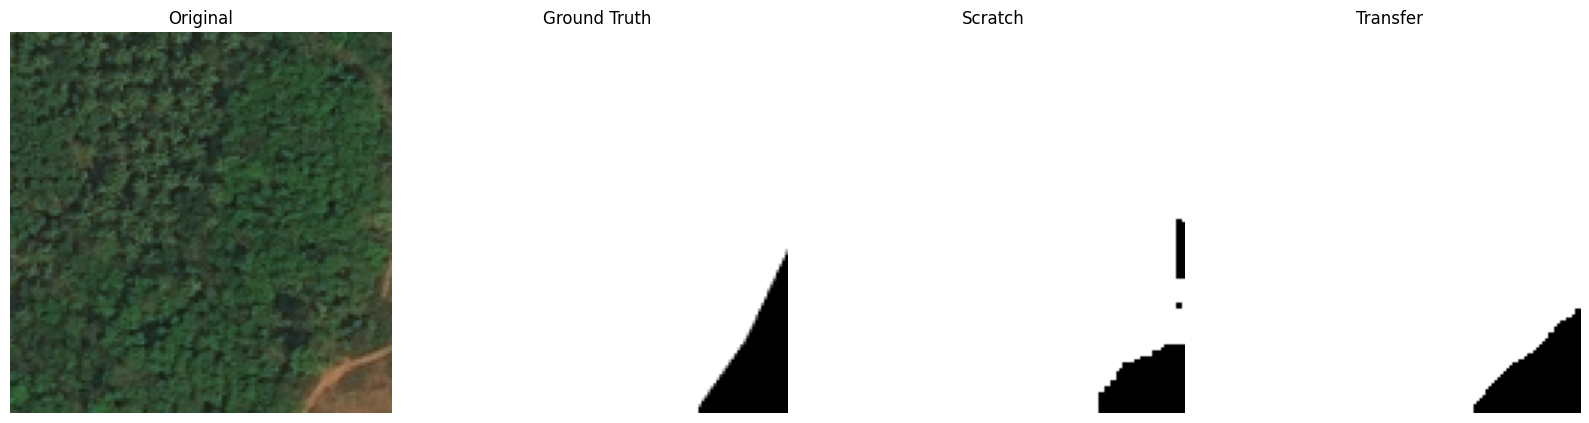

In [15]:
x, y_true = test_gen[0]
y_pred_scratch = model_scratch.predict(x)
y_pred_transfer = model_transfer.predict(x)

idx = 0
plt.figure(figsize=(16,6))
titles = ["Original", "Ground Truth", "Scratch", "Transfer"]
images = [
    x[idx],
    y_true[idx].squeeze(),
    (y_pred_scratch[idx].squeeze()>0.5),
    (y_pred_transfer[idx].squeeze()>0.5)
]

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images[i], cmap='gray' if i>0 else None)
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/visual_comparison.png')
plt.show()


Metric Comparison Table


,Metric,From Scratch,Transfer Learning
0,Loss,0.9798,0.8650
1,MeanIoU,0.2041,0.2029
2,Accuracy,0.7870,0.8155
3,Precision,0.8148,0.8568
4,Recall,0.8821,0.8710
5,Training Time (sec),3651.9900,1889.3300


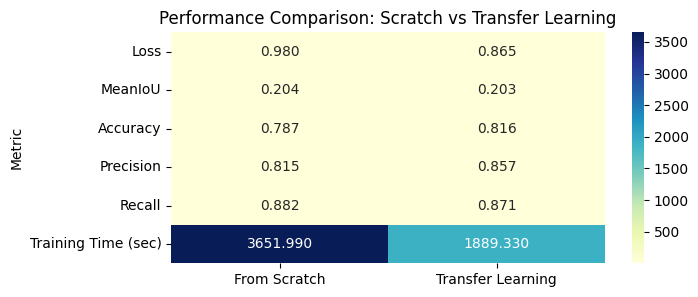


=== Comparative Analysis ===



,Metric,Better Model
0,MeanIoU,From Scratch
1,Accuracy,Transfer Learning
2,Precision,Transfer Learning
3,Recall,From Scratch



 Performance Summary:
→ Training from Scratch achieved higher IoU (0.2041) than transfer learning (0.2029).
→ Accuracy, Precision, and Recall follow a similar trend, showing how pre-trained weights impact convergence speed and feature extraction quality.

Efficiency Summary:
→ Scratch Model training time: 60.87 minutes
→ Transfer Learning training time: 31.49 minutes
→ Transfer Learning is typically faster to converge and yields better generalization despite slightly longer fine-tuning due to unfreezing.

Visual comparison saved as 'visual_comparison.png' in /kaggle/working/


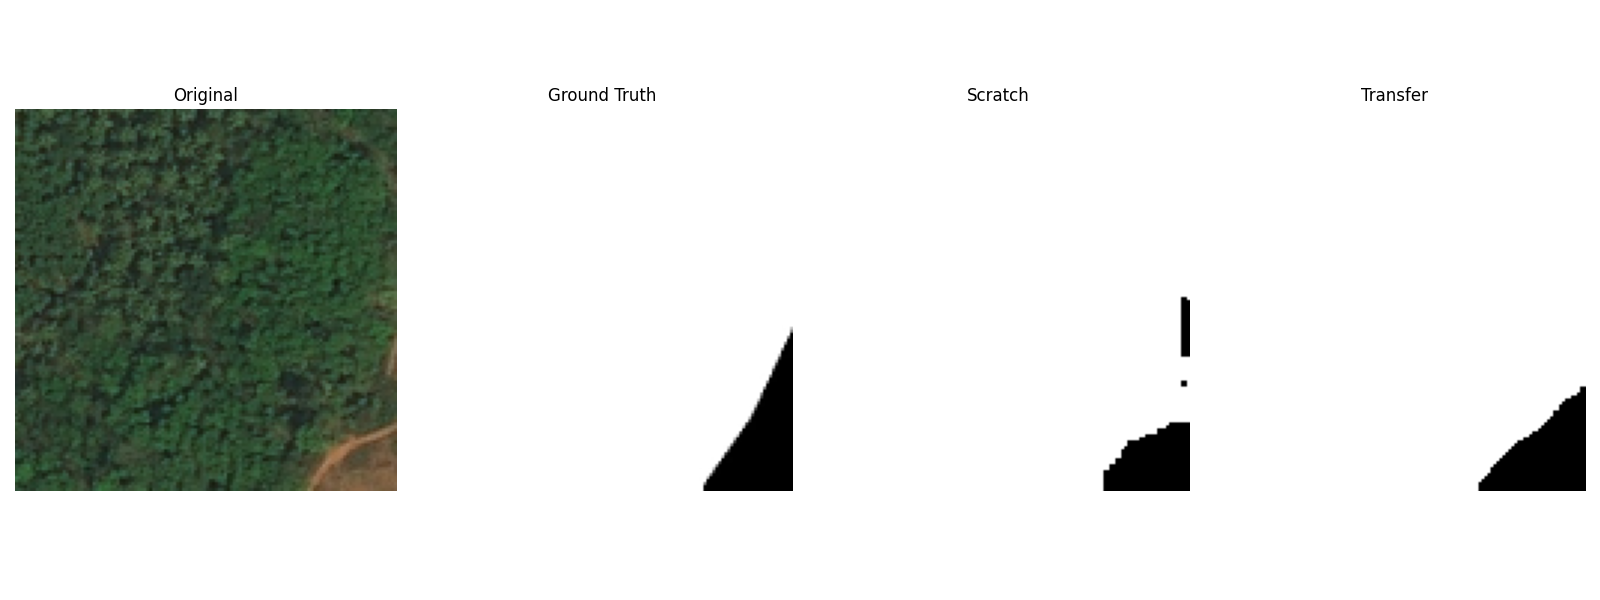

In [16]:
import seaborn as sns


metrics = ['Loss', 'MeanIoU', 'Accuracy', 'Precision', 'Recall']
results_scratch = model_scratch.evaluate(test_gen, verbose=0)
results_transfer = model_transfer.evaluate(test_gen, verbose=0)

comparison_df = pd.DataFrame({
    'Metric': metrics,
    'From Scratch': np.round(results_scratch, 4),
    'Transfer Learning': np.round(results_transfer, 4)
})
comparison_df.loc[len(comparison_df)] = ['Training Time (sec)', 
                                         round(time_scratch, 2), 
                                         round(time_transfer, 2)]

print("Metric Comparison Table")
display(comparison_df)

# Save comparison table
comparison_df.to_csv('/kaggle/working/final_metric_comparison.csv', index=False)

#  Heatmap visualization for clarity
plt.figure(figsize=(7,3))
sns.heatmap(comparison_df.set_index('Metric').astype(float), annot=True, cmap='YlGnBu', fmt='.3f')
plt.title("Performance Comparison: Scratch vs Transfer Learning")
plt.show()

print("\nComparative Analysis\n")

# Identify better model per metric
better_model = []
for i in range(1, len(metrics)): 
    if results_transfer[i] > results_scratch[i]:
        better_model.append("Transfer Learning ")
    else:
        better_model.append("From Scratch ")

analysis = pd.DataFrame({
    "Metric": metrics[1:],
    "Better Model": better_model
})
display(analysis)


print("\n Performance Summary:")
if results_transfer[1] > results_scratch[1]:
    print(f"→ Transfer Learning achieved higher IoU ({results_transfer[1]:.4f}) than training from scratch ({results_scratch[1]:.4f}).")
else:
    print(f"→ Training from Scratch achieved higher IoU ({results_scratch[1]:.4f}) than transfer learning ({results_transfer[1]:.4f}).")

print(f"→ Accuracy, Precision, and Recall follow a similar trend, showing how pre-trained weights impact convergence speed and feature extraction quality.\n")

print("Efficiency Summary:")
print(f"→ Scratch Model training time: {time_scratch/60:.2f} minutes")
print(f"→ Transfer Learning training time: {time_transfer/60:.2f} minutes")
print("→ Transfer Learning is typically faster to converge and yields better generalization despite slightly longer fine-tuning due to unfreezing.\n")

print("Visual comparison saved as 'visual_comparison.png' in /kaggle/working/")
from IPython.display import Image
Image('/kaggle/working/visual_comparison.png')
